In [ ]:
# Importing dependencies

from pathlib import Path
import pandas as pd
import numpy as np
import json
from dataclasses import dataclass, asdict
from sklearn.linear_model import LinearRegression
from scipy.stats import spearmanr


In [4]:
# Setup path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CUR = ROOT / "data" / "curated"
MET = ROOT / "data" / "metrics"
MODEL = ROOT / "models"
for p in [CUR, MET, MODEL]:
    p.mkdir(parents=True, exist_ok=True)

In [ ]:
# Config for model/training process
@dataclass
class CFG:
    lookback_weeks: int = 52
    min_assets_per_week: int = 10
    asset_cap: int = 30
    seed: int = 42
    out_pred: Path = CUR / "benchmark_preds_weekly.parquet"
    out_log: Path = MET / f"benchmark_train_logs_{pd.Timestamp.utcnow().strftime('%Y%m%d')}.json"

In [15]:
cfg = CFG()
print(cfg)

# Load data
df = pd.read_parquet(CUR / "factors_weekly.parquet")
uni = pd.read_parquet(CUR / "universe_top30_annual.parquet")

df["date_week"] = pd.to_datetime(df["date_week"]).dt.tz_localize(None)
uni["symbol"] = uni["symbol"].astype(str).str.upper()

# Asset key
ASSET_KEYS = ["market", "symbol", "coingecko_id"]
asset_key = next((k for k in ASSET_KEYS if k in df.columns), None)
if asset_key is None:
    asset_key = "_asset"; df["_asset"] = "asset_0"
if "symbol" in df.columns:
    df["symbol"] = df["symbol"].astype(str).str.upper()

# Target variable
if "rf_weekly" not in df.columns:
    # Assume risk-free rate to be 0.0 if not available
    df["rf_weekly"] = 0.0

df = df.sort_values([asset_key, "date_week"]).copy()
df["excess"] = df["ret_simple_weekly"] - df["rf_weekly"]
df["y_fwd1"] = df.groupby(asset_key)["excess"].shift(-1)

# Features
base_cols = [
    "log_mcap_year", "log_price", "max_price_week",
    "r1", "r2", "r3", "r4", "r4_1", "rmom3",
    "prcvol_mean_week", "prcvol_std_week", "vol_4w"
]

# Use z-standardized feature versions if available => else fallback to raw-features
fac_cols = [c + "_z" for c in base_cols if c + "_z" in df.columns]
if not fac_cols:
    fac_cols = [c for c in base_cols if c in df.columns]
print("features:", fac_cols)
display(df.head())

CFG(lookback_weeks=52, min_assets_per_week=10, asset_cap=30, seed=42, out_pred=PosixPath('/home/jannis/Desktop/university/WS25/FinTech/project/ml-crypto/data/curated/benchmark_preds_weekly.parquet'), out_log=PosixPath('/home/jannis/Desktop/university/WS25/FinTech/project/ml-crypto/data/metrics/benchmark_train_logs_20251012.json'))
features: ['log_mcap_year_z', 'log_price_z', 'max_price_week_z', 'r1_z', 'r2_z', 'r3_z', 'r4_z', 'r4_1_z', 'rmom3_z', 'prcvol_mean_week_z', 'prcvol_std_week_z', 'vol_4w_z']


,date_week,market,symbol,close,ret_simple_weekly,log_mcap_year,log_price,max_price_week,r1,r2,...,r3_z,r4_z,r4_1_z,rmom3_z,prcvol_mean_week_z,prcvol_std_week_z,vol_4w_z,rf_weekly,excess,y_fwd1
0,2018-04-29,ADA/USDT,ADA,0.36254,0.287429,23.649626,0.309351,0.38660,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.287429,-0.044133
1,2018-05-06,ADA/USDT,ADA,0.34654,-0.044133,23.649626,0.297538,0.38850,0.287429,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,-0.044133,-0.200150
2,2018-05-13,ADA/USDT,ADA,0.27718,-0.200150,23.649626,0.244655,0.34740,-0.044133,0.230611,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,-0.200150,-0.078000
3,2018-05-20,ADA/USDT,ADA,0.25556,-0.078000,23.649626,0.227582,0.27815,-0.200150,-0.235450,...,-0.121917,NaN,NaN,-0.062947,-0.507766,-0.430727,1.444747,0.0,-0.078000,-0.249257
4,2018-05-27,ADA/USDT,ADA,0.19186,-0.249257,23.649626,0.175515,0.25999,-0.078000,-0.262538,...,-1.154736,-0.661827,-0.661827,-1.327151,-0.526044,-0.506106,-0.241310,0.0,-0.249257,0.181017


In [9]:
# Filter by universe
df["year"] = df["date_week"].dt.year
df_u = df.merge(
    uni[["year", "symbol"]].drop_duplicates(),
    on=["year", "symbol"],
    how="inner"
)
print("rows (universe matched):", len(df_u))

rows (universe matched): 5650


In [16]:
# Filter tradable assets per week
def weekly_tradable(g: pd.DataFrame) -> pd.DataFrame:
    # Drop rows without target-feature
    g2 = g.dropna(subset=["y_fwd1"] + fac_cols)

    # If too many assets available, take assets with biggest log_mcap_year, log_price or just the first ones
    if len(g2) > cfg.asset_cap:
        if "log_mcap_year" in g2.columns:
            g2 = g2.sort_values("log_mcap_year", ascending=False).head(cfg.asset_cap)
        elif "log_price" in g2.columns:
            g2 = g2.sort_values("log_price", ascending=False).head(cfg.asset_cap)
        else:
            g2 = g2.head(cfg.asset_cap)
    return g2

blocks = []
for d, g in df_u.groupby("date_week"):
    gg = weekly_tradable(g)
    if len(gg) >= cfg.min_assets_per_week:
        blocks.append(gg)

df_tr = pd.concat(blocks, ignore_index=True).sort_values(["date_week", asset_key])
print("filtered rows:", len(df_tr), "weeks:", df_tr['date_week'].nunique(), "assets:", df_tr[asset_key].nunique())
display(df_tr.head())


filtered rows: 5420 weeks: 377 assets: 33


,date_week,market,symbol,close,ret_simple_weekly,log_mcap_year,log_price,max_price_week,r1,r2,...,r4_z,r4_1_z,rmom3_z,prcvol_mean_week_z,prcvol_std_week_z,vol_4w_z,rf_weekly,excess,y_fwd1,year
0,2018-07-08,ADA/USDT,ADA,0.14481,0.018999,23.649626,0.135239,0.16209,0.085389,-0.114248,...,-0.380990,-0.380990,0.775004,-0.432281,-0.682654,0.213359,0.0,0.018999,-0.017540,2018
1,2018-07-08,BTC/USDT,BTC,6712.10000,0.055891,26.193292,8.811816,6818.16000,0.035822,-0.014388,...,1.277492,1.277492,0.812162,2.862730,1.389997,-1.412823,0.0,0.055891,-0.053499,2018
2,2018-07-08,EOS/USDT,EOS,8.68270,0.069772,22.340998,2.270341,9.43630,0.006998,-0.214957,...,-0.958801,-0.958801,-0.434406,0.596316,0.301612,0.543625,0.0,0.069772,-0.146867,2018
3,2018-07-08,ETH/USDT,ETH,486.77000,0.076687,25.016053,6.189844,495.98000,-0.005084,-0.090598,...,0.481888,0.481888,-0.875555,0.497772,1.057785,-1.022610,0.0,0.076687,-0.075991,2018
4,2018-07-08,IOTA/USDT,MIOTA,1.07790,0.009742,23.012742,0.731358,1.26150,0.096897,-0.088853,...,-0.680828,-0.680828,0.620933,-0.575606,-1.063139,0.494191,0.0,0.009742,-0.074033,2018


In [ ]:
# Training loop
all_dates = sorted(df_tr["date_week"].unique())
pred_rows, log_items = [], []

for i, d in enumerate(all_dates):
    hist_dates = all_dates[:i]
    if len(hist_dates) < cfg.lookback_weeks:
        continue

    train_end = hist_dates[-1]
    train = df_tr[df_tr["date_week"] <= train_end].copy()
    test = df_tr[df_tr["date_week"] == d].copy()
    if len(test) < cfg.min_assets_per_week:
        continue

    X_tr = train[fac_cols].values
    y_tr = train["y_fwd1"].values
    X_te = test[fac_cols].values

    # Train Linear Regression model
    model = LinearRegression(fit_intercept=True)
    model.fit(X_tr, y_tr)
    y_hat = model.predict(X_te)

    out = test[["date_week", asset_key, "y_fwd1"]].copy()
    out["y_pred"] = y_hat
    pred_rows.append(out)

    # Log performance
    log_items.append({
        "asof_week": d.strftime("%Y-%m-%d"),
        "train_obs": len(X_tr),
        "test_obs": len(X_te),
    })

pred = pd.concat(pred_rows, ignore_index=True) if pred_rows else pd.DataFrame()
print("pred rows:", len(pred))



pred rows: 4754
Overall: {'linear_RankIC': np.float64(-0.0382504314589197), 'obs': 4754}
saved preds: /home/jannis/Desktop/university/WS25/FinTech/project/ml-crypto/data/curated/benchmark_preds_weekly.parquet
saved log: /home/jannis/Desktop/university/WS25/FinTech/project/ml-crypto/data/metrics/benchmark_train_logs_20251012.json


In [24]:
from sklearn.metrics import mean_squared_error, r2_score

# Model evaluation
if not pred.empty:
    print("\n--- Model Performance Evaluation ---")
    
    # Calculate overall metrics across all predictions.
    y_true = pred["y_fwd1"]
    y_pred = pred["y_pred"]
    
    overall_rank_ic = spearmanr(y_pred, y_true, nan_policy="omit").correlation
    overall_mse = mean_squared_error(y_true, y_pred)
    overall_r2 = r2_score(y_true, y_pred)
    
    print(f"Overall Rank IC (Spearman): {overall_rank_ic:.4f}")
    print(f"Overall Mean Squared Error (MAE): {overall_mse:.6f}")
    print(f"Overall R-squared (R²): {overall_r2:.4f}")

    # Weekly RankIC statistics
    # This is crucial for understanding model consistency => should have consistent positive RankIC and not be too volatile
    ic_rows = []
    mse_rows = []
    for d, g in pred.groupby("date_week"):
        if len(g) < cfg.min_assets_per_week:
            continue
        ic_rows.append({
            "date_week": d,
            "rank_ic": spearmanr(g["y_pred"], g["y_fwd1"], nan_policy="omit").correlation
        })

        mse_rows.append({
            "date_week": d,
            "mse": mean_squared_error(g["y_pred"], g["y_fwd1"])
        })
    
    if ic_rows:
        ic_by_week = pd.DataFrame(ic_rows).set_index("date_week")
        print("\n--- Weekly Rank IC Statistics ---")
        print(ic_by_week["rank_ic"].describe())
        
        # Calculate the percentage of weeks with a positive IC.
        positive_ic_ratio = (ic_by_week["rank_ic"] > 0).mean()
        print(f"\nPercentage of Weeks with Positive IC: {positive_ic_ratio:.2%}")

    # --- Saving Results ---
    # Save the predictions. This file can be used for backtesting a trading strategy.
    pred.to_parquet(cfg.out_pred, index=False)
    print(f"\nSaved predictions to: {cfg.out_pred}")

    # Save the configuration and performance logs.
    log_rec = {
        "config": asdict(cfg),
        "overall_metrics": {
            "rank_ic": overall_rank_ic,
            "mae": overall_mse,
            "r2": overall_r2,
            "positive_ic_ratio": positive_ic_ratio if ic_rows else None,
            "observations": int(len(pred))
        },
        "weekly_ic_stats": ic_by_week["rank_ic"].describe().to_dict() if ic_rows else None,
        "timeline": log_items
    }
    with open(cfg.out_log, "w") as f:
        json.dump(log_rec, f, indent=2, default=str)
    print(f"Saved training log to: {cfg.out_log}")
else:
    print("No predictions were generated. Check data and configuration.")


--- Model Performance Evaluation ---
Overall Rank IC (Spearman): -0.0383
Overall Mean Squared Error (MAE): 2021874.084552
Overall R-squared (R²): -0.0107

--- Weekly Rank IC Statistics ---
count    325.000000
mean      -0.048760
std        0.294390
min       -0.850000
25%       -0.264286
50%       -0.035714
75%        0.151648
max        0.764286
Name: rank_ic, dtype: float64

Percentage of Weeks with Positive IC: 43.38%

Saved predictions to: /home/jannis/Desktop/university/WS25/FinTech/project/ml-crypto/data/curated/benchmark_preds_weekly.parquet
Saved training log to: /home/jannis/Desktop/university/WS25/FinTech/project/ml-crypto/data/metrics/benchmark_train_logs_20251012.json


In [29]:
mse_by_week = pd.DataFrame(mse_rows).set_index("date_week")
mse_by_week.head()

,mse
date_week,
2019-07-07,0.058884
2019-07-14,0.006136
2019-07-21,0.010383
2019-07-28,0.003413
2019-08-04,0.003197


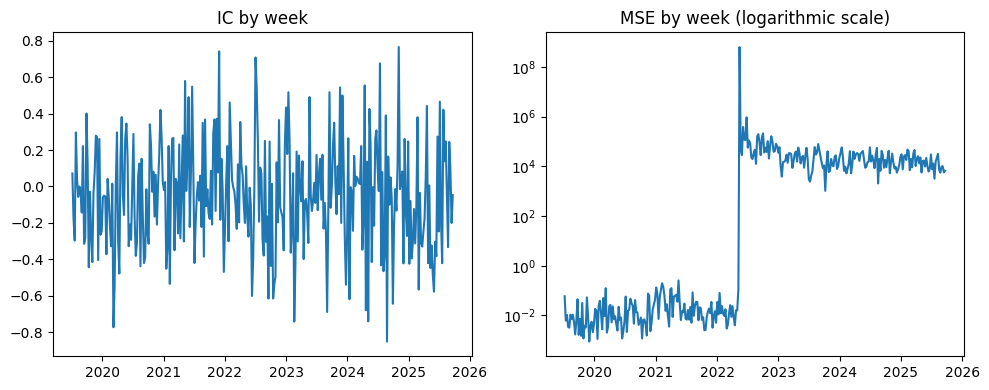

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

# subplot(nrows, ncols, index)
plt.subplot(1, 2, 1)  # 1 Reihe, 2 Spalten, erster Plot
plt.plot(ic_by_week)
plt.title("IC by week")

plt.subplot(1, 2, 2)  # 1 Reihe, 2 Spalten, zweiter Plot
plt.plot(mse_by_week)
plt.yscale("log")
plt.title("MSE by week (logarithmic scale)")

plt.tight_layout()
plt.show()